In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
Step 1 : Understanding Data

In [4]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/farazmirza01/house-rate-dataset-for-predictive-analysis/House Rate Data.csv')

In [5]:
df.head(5)

,Date,Rates or Price,Bedrooms,Bathrooms,Sqft_Living,Sqft_lot,Floors,Waterfront,view,Condition,Sqft_Above,Sqft_Basement
0,02-05-2014,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0
1,02-05-2014,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280
2,02-05-2014,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0
3,02-05-2014,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000
4,02-05-2014,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800


In [7]:
df.tail(5)

,Date,Rates or Price,Bedrooms,Bathrooms,Sqft_Living,Sqft_lot,Floors,Waterfront,view,Condition,Sqft_Above,Sqft_Basement
4595,09-07-2014,308166.6667,3,1.75,1510,6360,1.0,0,0,4,1510,0
4596,09-07-2014,534333.3333,3,2.50,1460,7573,2.0,0,0,3,1460,0
4597,09-07-2014,416904.1667,3,2.50,3010,7014,2.0,0,0,3,3010,0
4598,10-07-2014,203400.0000,4,2.00,2090,6630,1.0,0,0,3,1070,1020
4599,10-07-2014,220600.0000,3,2.50,1490,8102,2.0,0,0,4,1490,0


In [20]:
df.describe()

,Rates or Price,Bedrooms,Bathrooms,Sqft_Living,Sqft_lot,Floors,Waterfront,view,Condition,Sqft_Above,Sqft_Basement
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000


In [16]:
df.shape

(4600, 12)

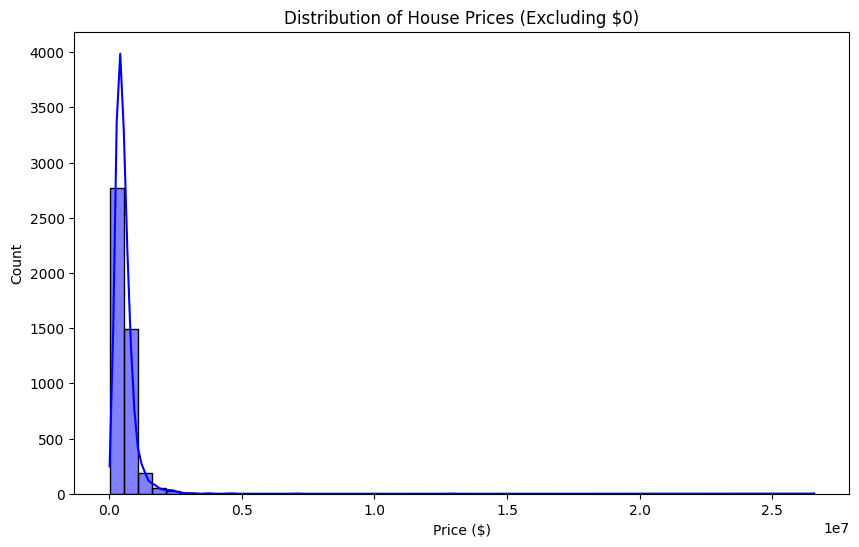

In [21]:
# 1. Visualize the distribution of House Prices
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Rates or Price'] > 0]['Rates or Price'], bins=50, kde=True, color='blue')
plt.title('Distribution of House Prices (Excluding $0)')
plt.xlabel('Price ($)')
plt.show()

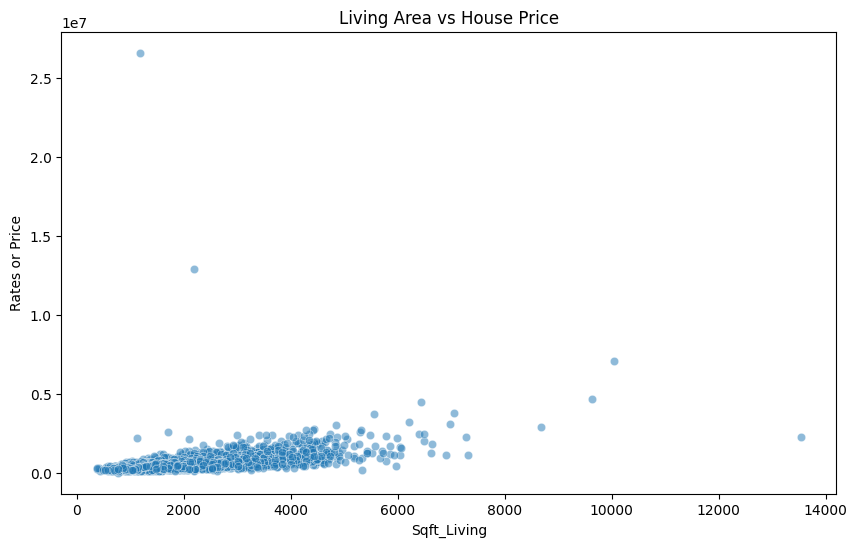

In [23]:
# 2. Relationship between Sqft_Living and Price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['Rates or Price'] > 0], x='Sqft_Living', y='Rates or Price', alpha=0.5)
plt.title('Living Area vs House Price')
plt.show()

In [ ]:
Step 2: Data Cleaning & Preprocessing

In [25]:
from sklearn.model_selection import train_test_split

# 1. Remove entries where price is 0 (likely data errors or non-sales)
df_cleaned = df[df['Rates or Price'] > 0].copy()

# 2. Convert Date to useful features (Year and Month)
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], dayfirst=True)
df_cleaned['Sale_Year'] = df_cleaned['Date'].dt.year
df_cleaned['Sale_Month'] = df_cleaned['Date'].dt.month

# 3. Define Features (X) and Target (y)
# We drop 'Date' and 'Rates or Price' from features
X = df_cleaned.drop(['Rates or Price', 'Date'], axis=1)
y = df_cleaned['Rates or Price']

# 4. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 3640
Testing samples: 911


In [ ]:
Step 3: Model Training (Random Forest Regressor)
For house price prediction, Random Forest is highly effective because it handles the complex relationships between features (like how a "Waterfront" view multiplies the value of "Sqft_Living").

Mean Absolute Error: $166,677.64
Model Accuracy (R² Score): 0.51


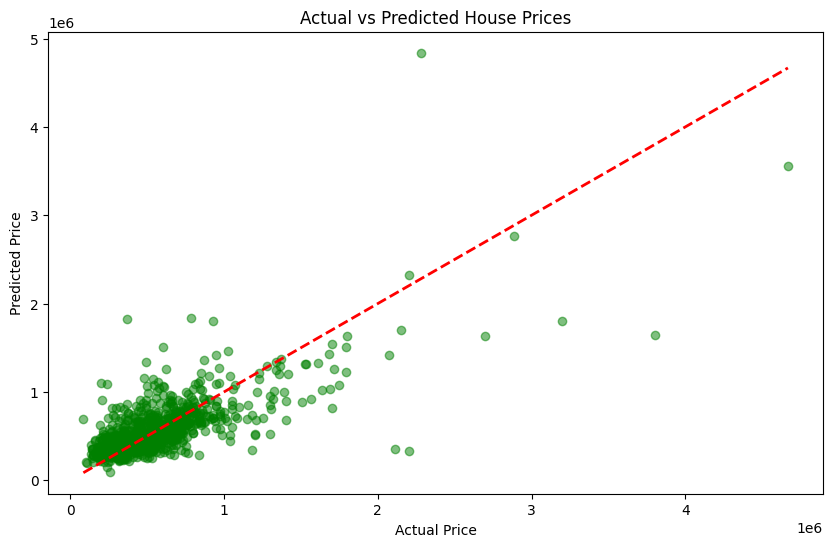

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Initialize the Model
# Random Forest is robust and handles outliers well
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the Model
model.fit(X_train, y_train)

# 3. Make Predictions on the Test Set
y_pred = model.predict(X_test)

# 4. Evaluate Performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"Model Accuracy (R² Score): {r2:.2f}")

# Visualize Predicted vs Actual Prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

In [ ]:
Step 4: Identifying Feature Importance
This helps brokers explain to clients why a house is priced a certain way.

/tmp/ipykernel_55/1819026967.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


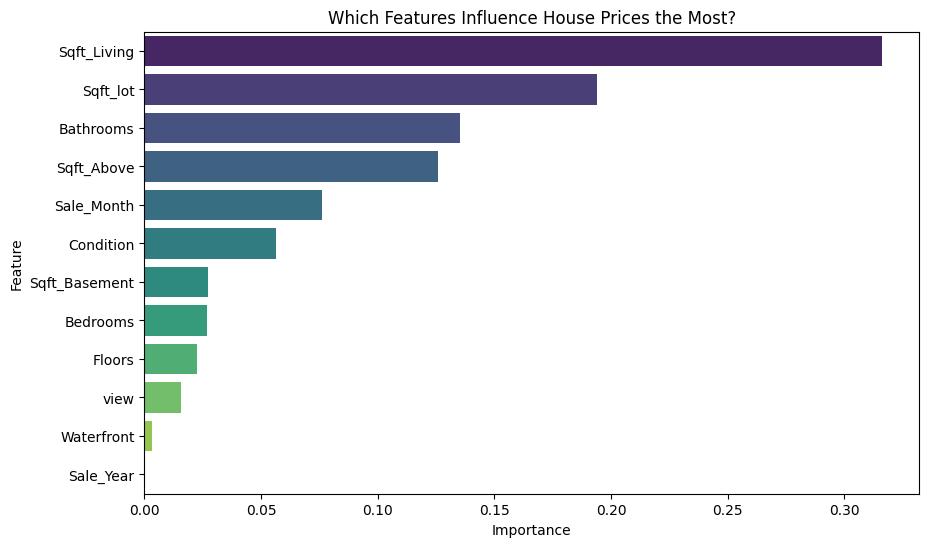

In [31]:
# Extract feature importance
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Features Influence House Prices the Most?')
plt.show()

In [ ]:
Key Summary for Brokers:
Sqft_Living is usually the most significant predictor of price.

The R² Score (Accuracy) tells you how much of the price variation is explained by the model. A score above 0.70 is generally considered strong for real estate.

The Mean Absolute Error (MAE) gives you the average dollar amount the model is "off" by—useful for setting client expectations.